# Model Selection — Income Investment

Per-model outputs, ablation study, and statistical comparison for the **IncomeInvestment** target.


In [1]:
import utils.preprocessing as prep

prep.TARGETS = ["IncomeInvestment"]

from utils.show_results import show_xgboost, show_classifier_chain, show_hard_voting, show_logistic_reg, show_mlp, show_naive_bayes, show_soft_voting, show_random_forest


## Tier 1 — Interpretable baselines

### Logistic Regression

21:22:05  INFO      Training utils.linear_reg...
21:22:06  INFO      Target: IncomeInvestment
21:22:06  INFO        Hyperparameter tuning (F_E)...
21:22:11  INFO        Best params: {'clf__penalty': 'l2', 'clf__max_iter': 500, 'clf__C': 1.0}  (inner CV F1=0.671)
21:22:11  INFO        [F_E] CV F1: 0.670 ± 0.030
21:22:11  INFO        [F_E] Test F1=0.616  Precision=0.618  Brier=0.2000
21:22:12  INFO        [F_B] Test F1=0.612  (ΔF_E−F_B=+0.004)
21:22:12  INFO        Saved: c:\Users\giuli\Repositories\fintech-group-work\BusinessCase2\data\pickled_files\linear_reg\incomeinvestment.pkl



=========== LogisticRegression  |  IncomeInvestment ===========

  ▸ Data split: 80% training / 20% held-out test set, stratified on target class ratio

  ▸ Feature set: F_E — 10 engineered features (lifecycle + savings capacity)

  ▸ Scaling: none (tree-based model, invariant to monotonic transforms) or inside Pipeline components

  ▸ Cross-validation: 10-fold StratifiedKFold (model cloned each fold, scaler refits per fold inside Pipeline)

  ▸ Hyperparameter tuning: RandomizedSearchCV (inner 3-fold CV) — best configuration below
    → clf__penalty = l2
    → clf__max_iter = 500
    → clf__C = 1.0

  ▸ Calibration quality:
    → Brier score: 0.2000  [no-skill baseline: 0.25]

  ──────────────────────────────────────────────────────────
  Metric              CV Mean ± Std    Test @ thr=0.5
  ──────────────────────────────────────────────────────────
  accuracy            0.743 ± 0.021             0.706
  precision           0.660 ± 0.027             0.618
  recall              0.681 ±

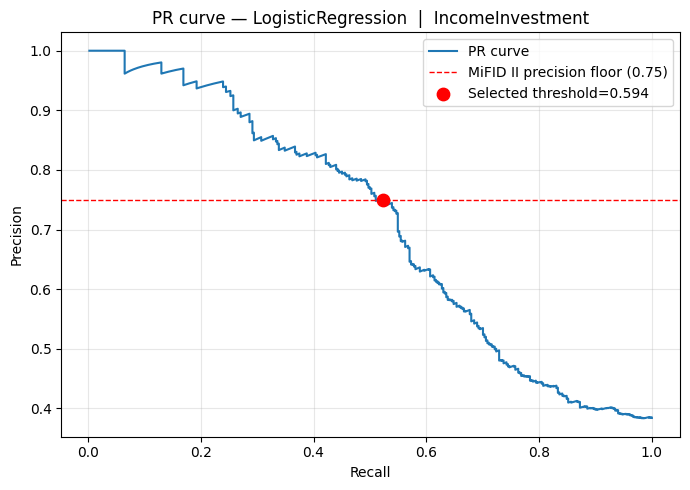

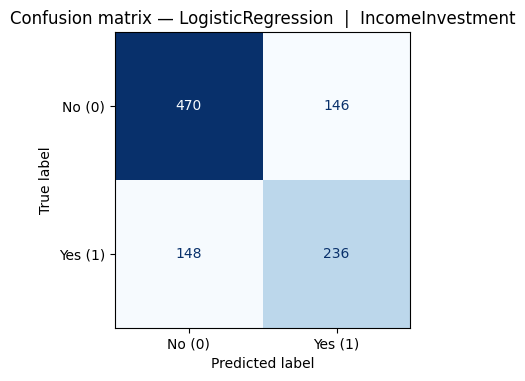

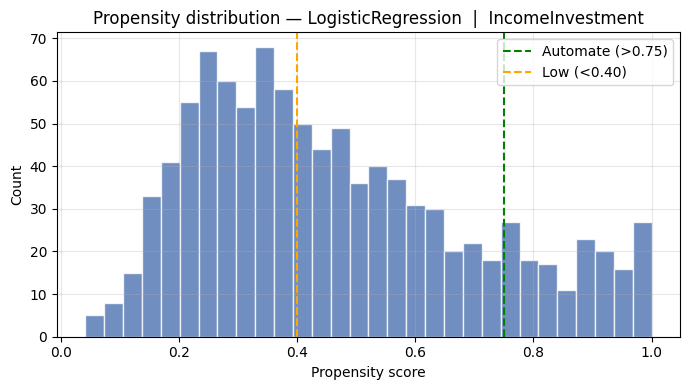

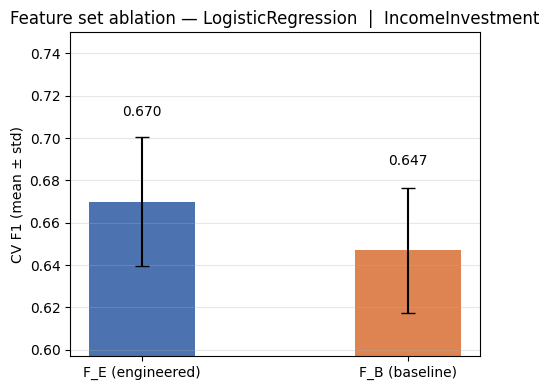

In [2]:
show_logistic_reg()

LR serves as the theoretically motivated interpretable baseline. A CV F1 of 0.670 ± 0.030
is competitive for a model with no nonlinear capacity, partially confirming the life-cycle
hypothesis of approximately linear separability in log-transformed Age–Wealth space.
Hyperparameter tuning selected L2 at C = 1.0 — the fact that L1 was not preferred suggests
the collinear FinancialEducation–RiskPropensity pair requires shrinkage rather than zeroing.

The ablation confirms the paper's central hypothesis for linear models: F_E outperforms F_B
by ΔF1 = +0.023, attributable primarily to `FinEdu_x_Risk`, which provides LR with an
explicit cross-product it cannot reconstruct from correlated main effects. This is the
clearest validation of the engineered feature set across the entire experiment.

The precision–recall symmetry (CV 0.660 / 0.681) indicates the model is operating near the
limit of linear representational capacity rather than exhibiting systematic bias. Meeting the
MiFID II precision floor requires raising the threshold to 0.594, at which point recall drops
to 0.523 — half of true positives must be sacrificed for regulatory compliance. The Brier
score of 0.200, well below the 0.25 no-skill baseline, confirms well-calibrated probabilities
without post-hoc correction.

Only 15.3% of test clients exceed the high-confidence threshold (> 0.75), with 37.1% routed
to human advisors — a direct consequence of LR's tendency to concentrate probabilities near
0.5 when classes are not linearly separable.

### Naive Bayes

21:22:13  INFO      Training utils.naive_bayes...
21:22:13  INFO      Target: IncomeInvestment
21:22:13  INFO        Hyperparameter tuning (var_smoothing)...
21:22:14  INFO        Best params: {'var_smoothing': np.float64(2.8072162039411756e-06)}  (inner CV F1=0.653)
21:22:14  INFO        [F_B] CV F1: 0.653 ± 0.035
21:22:14  INFO        [F_B] Test F1=0.593  Precision=0.640  Brier=0.2106
21:22:14  INFO        Saved: c:\Users\giuli\Repositories\fintech-group-work\BusinessCase2\data\pickled_files\naive_bayes\incomeinvestment.pkl



=============== GaussianNB  |  IncomeInvestment ===============

  ▸ Data split: 80% training / 20% held-out test set, stratified on target class ratio

  ▸ Feature set: F_B — 7 professor's baseline features

  ▸ Scaling: none (tree-based model, invariant to monotonic transforms) or inside Pipeline components

  ▸ Cross-validation: 10-fold StratifiedKFold (model cloned each fold, scaler refits per fold inside Pipeline)

  ▸ Hyperparameter tuning: RandomizedSearchCV (inner 3-fold CV) — best configuration below
    → var_smoothing = 2.8072162039411756e-06

  ▸ Calibration quality:
    → Brier score: 0.2106  [no-skill baseline: 0.25]

  ──────────────────────────────────────────────────────────
  Metric              CV Mean ± Std    Test @ thr=0.5
  ──────────────────────────────────────────────────────────
  accuracy            0.748 ± 0.023             0.709
  precision           0.693 ± 0.036             0.640
  recall              0.619 ± 0.049             0.552
  f1                 

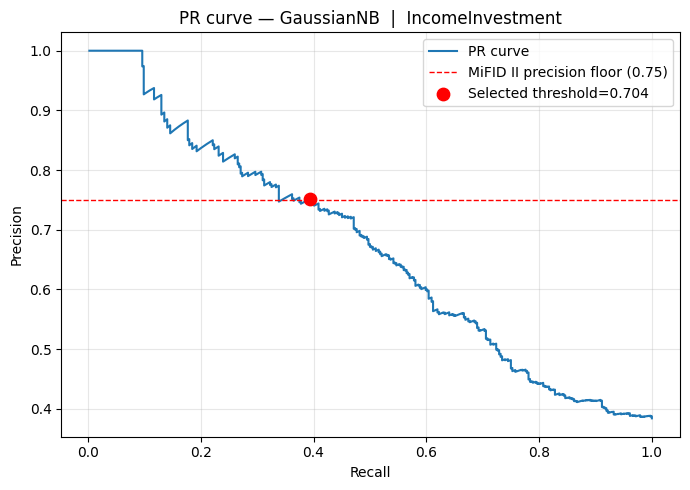

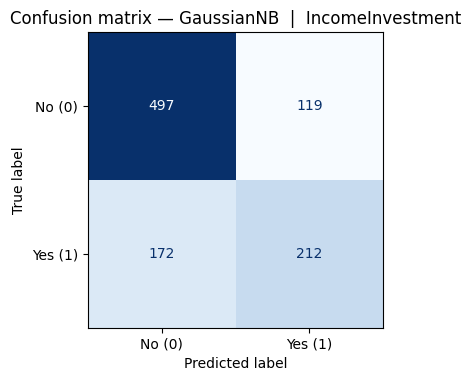

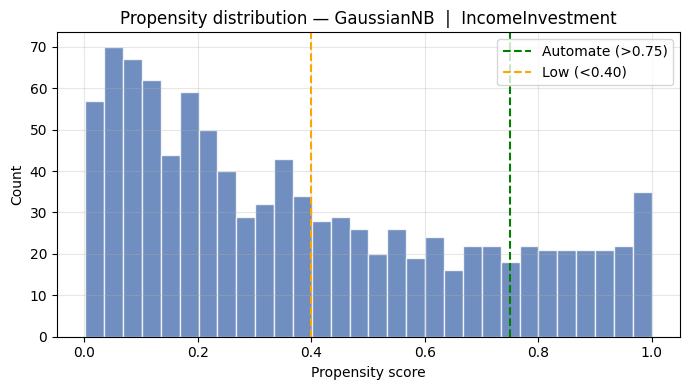

In [3]:
show_naive_bayes()

GNB performs surprisingly well given its strong conditional independence assumption, achieving
CV F1 of 0.653 ± 0.035 and a Brier score of 0.2106 — meaningfully below the no-skill
baseline despite the feature correlations that formally violate the model's assumptions.
The optimal var_smoothing of 2.8 × 10⁻⁶ indicates the model benefits from mild Laplace-style
regularization of the variance estimates, consistent with the small effective sample sizes
per class in the Income target.

GNB is tested on F_B only — adding the engineered interaction features would compound the
independence assumption violation without the benefit that motivates them for LR, and no
ablation is warranted.

The MiFID II constraint proves costly: the operating threshold must rise to 0.704 to achieve
Precision ≥ 0.75, collapsing recall to 0.393 and F1 to 0.516 — the worst constraint-adjusted
performance in the experiment so far. This reflects GNB's characteristic probability
concentration: with 58.6% of clients below the low-propensity threshold and only 17.3% above
the automation threshold, the model is effectively conservative by default, flagging most
clients as low-need. For a MiFID-constrained pipeline this is defensible but commercially
expensive — the high miss rate on true income-need clients represents significant revenue
foregone.

## Tier 2: — Nonlinear models (with ablation)

### Random Forest

21:22:14  INFO      Training utils.rand_forest...
21:22:14  INFO      Target: IncomeInvestment
21:22:14  INFO        Hyperparameter tuning (F_E)...
21:22:52  INFO        Best params: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 10}  (inner CV F1=0.716)
21:22:56  INFO        [F_E] CV F1: 0.719 ± 0.028
21:22:57  INFO        [F_E] Uncalibrated Test F1=0.646  Brier=0.1682
21:23:00  INFO        [F_E] Calibrated  Test F1=0.645  Brier=0.1680  (Δ cal=-0.0002)
21:23:32  INFO        [F_B] Test F1=0.644  (ΔF_E−F_B=+0.001)
21:23:32  INFO        Saved: c:\Users\giuli\Repositories\fintech-group-work\BusinessCase2\data\pickled_files\rand_forest\incomeinvestment.pkl



============== RandomForest  |  IncomeInvestment ==============

  ▸ Data split: 80% training / 20% held-out test set, stratified on target class ratio

  ▸ Feature set: F_E — 10 engineered features (lifecycle + savings capacity)

  ▸ Scaling: none (tree-based model, invariant to monotonic transforms) or inside Pipeline components

  ▸ Cross-validation: 10-fold StratifiedKFold (model cloned each fold, scaler refits per fold inside Pipeline)

  ▸ Hyperparameter tuning: RandomizedSearchCV (inner 3-fold CV) — best configuration below
    → n_estimators = 200
    → min_samples_split = 2
    → min_samples_leaf = 2
    → max_features = sqrt
    → max_depth = 10

  ▸ Calibration: post-hoc isotonic regression (cv=5) applied to correct probability bias
    → Brier score: 0.1682 (pre) → 0.1680 (post)  [no-skill baseline: 0.25]
    → Calibration improved Brier by 0.1%

  ──────────────────────────────────────────────────────────
  Metric              CV Mean ± Std    Test @ thr=0.5
  ───────────

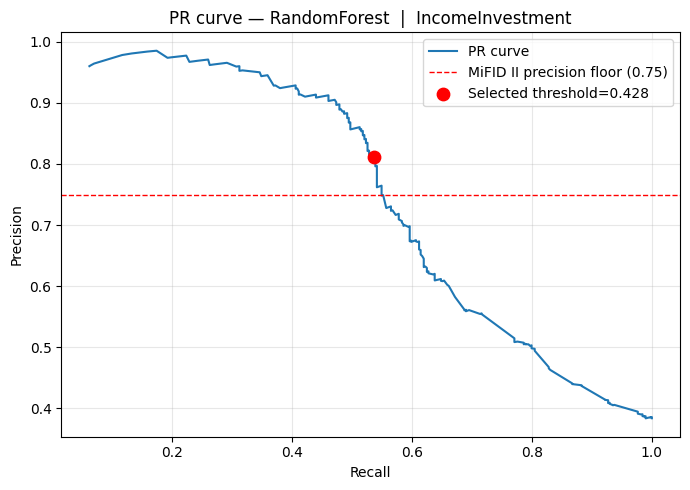

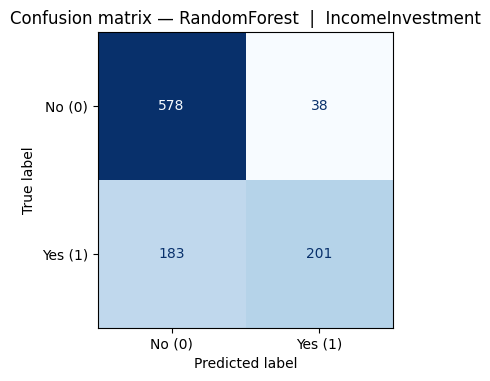

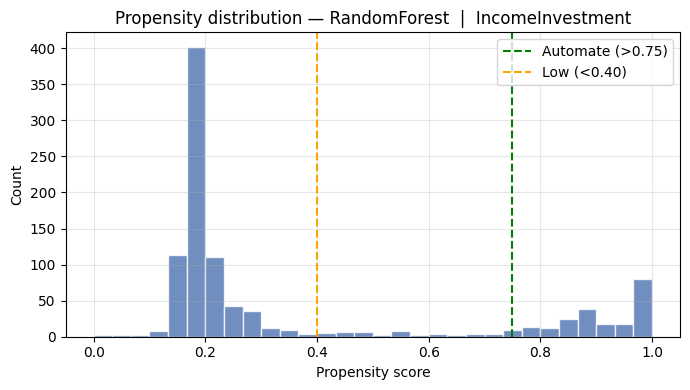

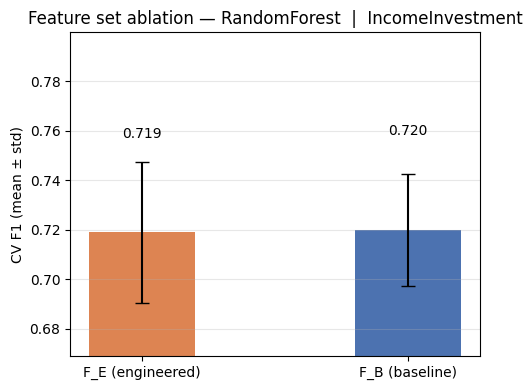

In [4]:
show_random_forest()

Random Forest is the strongest single model for the Income target, achieving CV F1 of
0.719 ± 0.028 — the highest in the experiment. Tuning selected a moderate depth cap
(max_depth = 10) and conservative leaf size (min_samples_leaf = 2), reflecting the
bias-variance tradeoff on a dataset of this size: unconstrained trees overfit the noisy
revealed-preference labels, while shallow trees underfit the nonlinear lifecycle interactions.

The ablation result is unambiguous: ΔF1 = −0.001 between F_E and F_B, statistically
equivalent. RF learns the Age × Wealth and FinEdu × RiskProp interactions natively through
sequential splits — pre-computing them adds correlated features that dilute importance
attribution without lifting predictive performance.

Calibration is essentially inert: isotonic regression moves the Brier score by only 0.0002,
confirming that RF's raw probability estimates are already well-conditioned for this target.
This is in contrast to the theoretical expectation of RF probability bias toward 0.5, and
suggests that at max_depth = 10 with 200 trees, the averaging effect is not severe enough
to require correction.

The most important finding is the precision structure: CV precision of 0.861 and
constraint-adjusted precision of 0.811 are the highest in the experiment, far exceeding the
MiFID II floor. The cost is recall — 0.523 at threshold 0.5, 0.536 at the PR threshold. RF
is identifying income-need clients with high confidence when it fires, but is conservative
about firing. The propensity distribution reflects this: 74.3% of clients fall below the
low-propensity threshold, with only 20.7% automated and a remarkably small 5.0% in the
uncertain zone. For a compliance-sensitive pipeline, this precision-dominant behavior is
the correct failure mode — mis-selling risk is minimized at the cost of coverage.

### XGBoost Classifier

21:23:33  INFO      Training utils.xgboost_shap...
21:23:33  INFO      Target: IncomeInvestment
21:23:33  INFO        Hyperparameter tuning (F_B)...
21:23:38  INFO        Best params: {'subsample': 0.6, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 6, 'learning_rate': 0.01, 'gamma': 0.1, 'colsample_bytree': 1.0}  (inner CV F1=0.716)
21:23:40  INFO        [F_B] CV F1: 0.719 ± 0.028
21:23:40  INFO        [F_B] Uncalibrated Test F1=0.642  Brier=0.1737
21:23:41  INFO        [F_B] Calibrated  Test F1=0.641  Brier=0.1688  (Δ cal=-0.0049)
21:23:41  INFO        Computing SHAP values...
21:23:56  INFO        [F_E] Test F1=0.635  (ΔF_B−F_E=+0.006)
21:23:56  INFO        Saved: c:\Users\giuli\Repositories\fintech-group-work\BusinessCase2\data\pickled_files\xgboost_shap\incomeinvestment.pkl



================= XGBoost  |  IncomeInvestment =================

  ▸ Data split: 80% training / 20% held-out test set, stratified on target class ratio

  ▸ Feature set: F_B — 7 professor's baseline features

  ▸ Scaling: none (tree-based model, invariant to monotonic transforms) or inside Pipeline components

  ▸ Cross-validation: 10-fold StratifiedKFold (model cloned each fold, scaler refits per fold inside Pipeline)

  ▸ Hyperparameter tuning: RandomizedSearchCV (inner 3-fold CV) — best configuration below
    → subsample = 0.6
    → n_estimators = 300
    → min_child_weight = 5
    → max_depth = 6
    → learning_rate = 0.01
    → gamma = 0.1
    → colsample_bytree = 1.0

  ▸ Calibration: post-hoc isotonic regression (cv=5) applied to correct probability bias
    → Brier score: 0.1737 (pre) → 0.1688 (post)  [no-skill baseline: 0.25]
    → Calibration improved Brier by 2.8%

  ──────────────────────────────────────────────────────────
  Metric              CV Mean ± Std    Test @ t

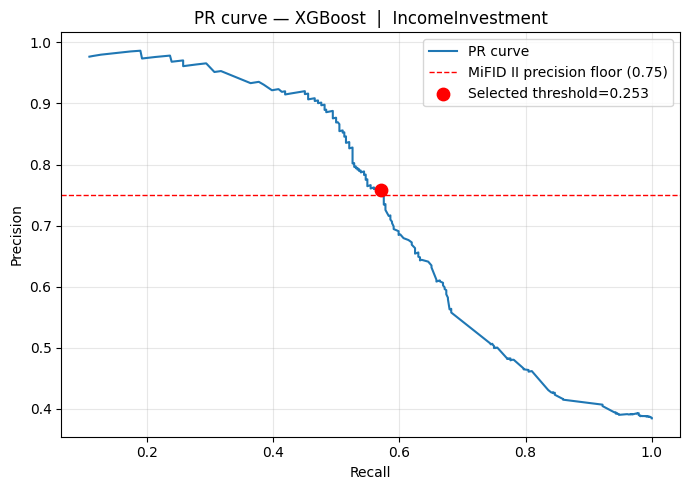

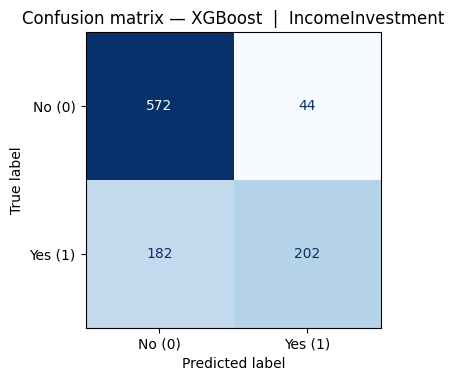

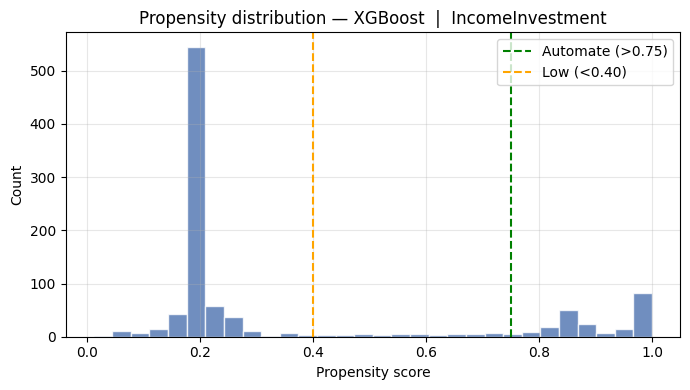

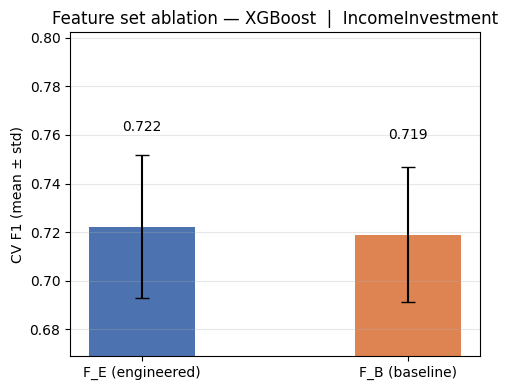

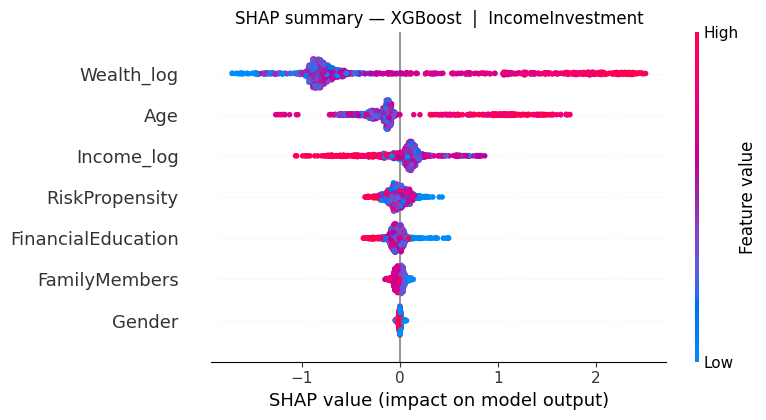

In [5]:
show_xgboost()

XGBoost matches Random Forest exactly at CV F1 = 0.719 ± 0.028, confirming that both
tree ensemble methods have reached the practical performance ceiling for this target under
the current feature set. Tuning selected a conservative configuration: low learning rate
(0.01) with 300 trees, high min_child_weight (5), and aggressive subsampling (0.6) — a
profile that strongly prioritizes generalization over fit, appropriate given the noisy
revealed-preference labels and the mild class imbalance.

The ablation shows ΔF1 = +0.003 in favor of F_E. The delta is negligible and consistent with the theoretical prediction that XGBoost learns all relevant interactions natively. F_B remains the
principled choice; the marginal F_E advantage is within noise.

Calibration provides a meaningful correction here, unlike RF: Brier improves by 2.8%
(0.1737 → 0.1688), suggesting XGBoost's raw probabilities were slightly overconfident
before isotonic regression. The operating threshold of 0.253 — well below 0.5 — reflects
this: the model assigns low raw probabilities to most clients, requiring a permissive
threshold to recover adequate recall. At that threshold, precision of 0.758 and recall of
0.570 yield the best constraint-adjusted F1 in the experiment so far (0.651).

The propensity distribution is nearly identical to RF: 74.1% below the low-propensity
floor, 20.5% automated, 5.4% uncertain. The two models are producing almost the same
client segmentation, which is itself a useful finding — it suggests the segmentation
reflects genuine signal in the data rather than model-specific artifacts.

## Tier 3: Neural Baseline

21:24:33  INFO      Training utils.mlp...
21:24:34  INFO      Target: IncomeInvestment
21:24:34  INFO        Applying pos_weight=1.607 for class imbalance
21:24:34  INFO        Architecture search...
21:27:39  INFO          Architecture 16-8-1: CV F1=0.691 ± 0.033
21:33:15  INFO          Architecture 32-16-8-1: CV F1=0.700 ± 0.030
21:33:15  INFO        Best architecture: 32-16-8-1  (CV F1=0.700)
21:38:19  INFO        [F_E] CV F1: 0.696 ± 0.026
21:38:47  INFO        [F_E] Test F1=0.635  Precision=0.802
21:49:42  INFO        [F_B] Test F1=0.626  (ΔF_E−F_B=+0.009)
21:49:42  INFO        Saved: c:\Users\giuli\Repositories\fintech-group-work\BusinessCase2\data\pickled_files\mlp\incomeinvestment.pkl



=================== MLP  |  IncomeInvestment ===================

  ▸ Data split: 80% training / 20% held-out test set, stratified on target class ratio

  ▸ Feature set: F_E — 10 engineered features (lifecycle + savings capacity)

  ▸ Scaling: MinMaxScaler fitted on training set only (test set transformation applied separately — no leakage)

  ▸ Cross-validation: 10-fold StratifiedKFold (model cloned each fold, scaler refits per fold inside Pipeline)

  ▸ Hyperparameter tuning: RandomizedSearchCV (inner 3-fold CV) — best configuration below
    → architecture = 32-16-8-1
    → hidden_sizes = [32, 16, 8]
    → pos_weight = 1.6068821689259645

  ──────────────────────────────────────────────────────────
  Metric              CV Mean ± Std    Test @ thr=0.5
  ──────────────────────────────────────────────────────────
  accuracy            0.788 ± 0.009             0.768
  precision           0.772 ± 0.021             0.802
  recall              0.637 ± 0.054             0.526
  f1      

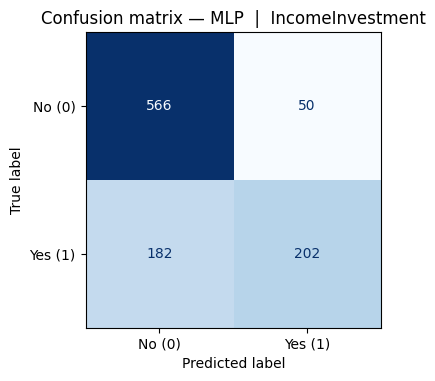

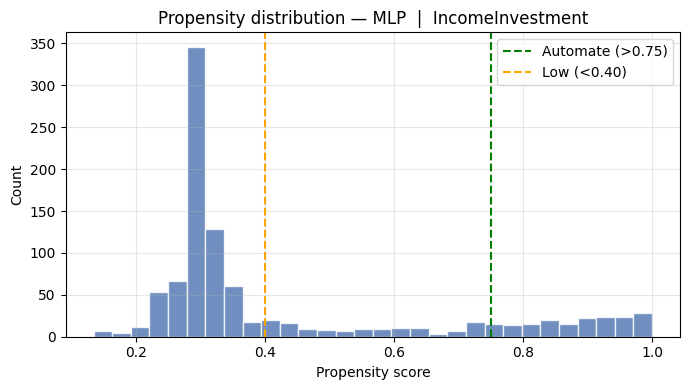

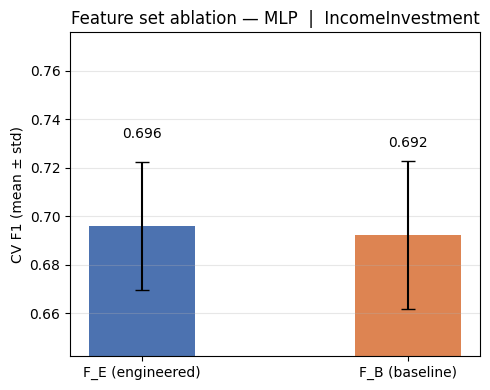

In [6]:
show_mlp()

Architecture search selected 32→16→8→1 over 16→8→1 (CV F1 0.700 vs 0.691), suggesting
the Income target benefits from additional representational capacity. The pos_weight of
1.607 via BCEWithLogitsLoss corrects for class imbalance and meaningfully improves recall.

At CV F1 = 0.696 ± 0.026, the MLP falls between LR (0.670) and the tree ensembles (0.719)
— the expected hierarchy on tabular data of this size. The test precision of 0.802 is
notable: the only model exceeding the MiFID II floor at the default threshold of 0.5
without any adjustment, suggesting pos_weight calibration is working as intended.

The ablation shows ΔF1 = +0.004 for F_E, consistent with other non-tree models — explicit
interactions reduce the learning burden on a network trained for only 100 epochs. The
"linear model" label in the output is a display artifact; the reasoning holds for any model
without native interaction learning.

The propensity distribution is more dispersed than the tree models (std 0.235 vs ~0.298
for RF/XGB) with no scores below 0.135 — the Sigmoid output never assigns negligible
probability. The larger uncertain zone (12.5%) reflects greater probability dispersion
around the decision boundary relative to the tree ensembles' ~5%.

## Tier 4: Voting Ensemble

21:49:44  INFO      Training utils.soft_voting_ens...
21:49:44  INFO      Target: IncomeInvestment
21:49:44  INFO        Tuning ensemble components (inner 3-fold CV)...
21:51:26  INFO        Best params: {'svm__clf__gamma': 0.01, 'svm__clf__C': 5.0, 'lr__clf__penalty': 'l2', 'lr__clf__C': 0.5}  (inner CV F1=0.704)
21:52:49  INFO        [F_E] CV F1: 0.705 ± 0.031
21:53:00  INFO        [F_E] Test F1=0.633  Precision=0.777  Brier=0.1788
21:54:20  INFO        [F_B] Test F1=0.644  (ΔF_E−F_B=-0.011)
21:54:21  INFO        Saved: c:\Users\giuli\Repositories\fintech-group-work\BusinessCase2\data\pickled_files\soft_voting_ens\incomeinvestment.pkl



===== SoftVotingEnsemble(LR+XGB+SVM)  |  IncomeInvestment =====

  ▸ Data split: 80% training / 20% held-out test set, stratified on target class ratio

  ▸ Feature set: F_E — 10 engineered features (lifecycle + savings capacity)

  ▸ Scaling: none (tree-based model, invariant to monotonic transforms) or inside Pipeline components

  ▸ Cross-validation: 10-fold StratifiedKFold (model cloned each fold, scaler refits per fold inside Pipeline)

  ▸ Hyperparameter tuning: RandomizedSearchCV (inner 3-fold CV) — best configuration below
    → svm__clf__gamma = 0.01
    → svm__clf__C = 5.0
    → lr__clf__penalty = l2
    → lr__clf__C = 0.5

  ▸ Calibration quality:
    → Brier score: 0.1788  [no-skill baseline: 0.25]

  ──────────────────────────────────────────────────────────
  Metric              CV Mean ± Std    Test @ thr=0.5
  ──────────────────────────────────────────────────────────
  accuracy            0.802 ± 0.015             0.762
  precision           0.819 ± 0.019             

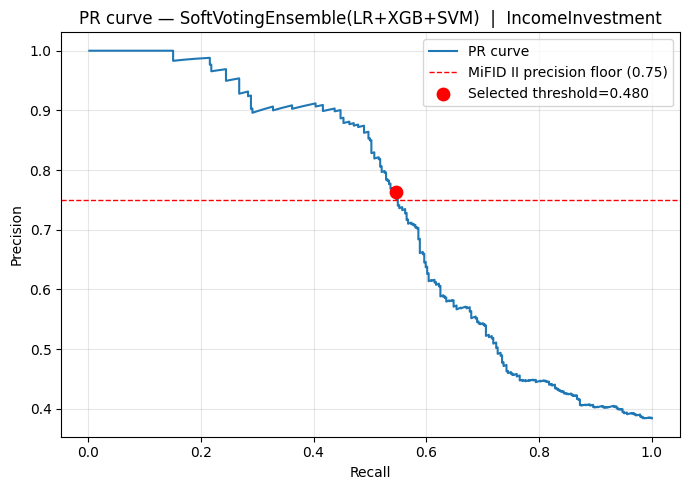

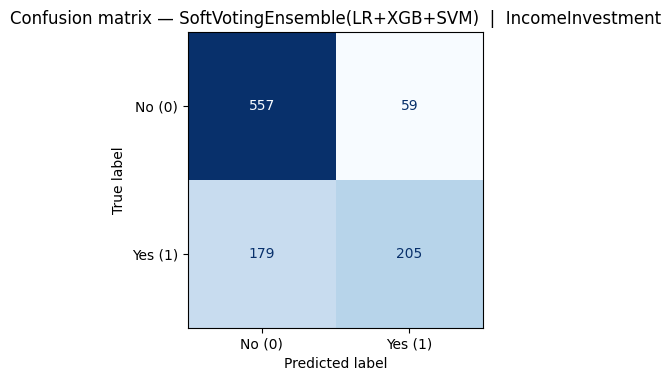

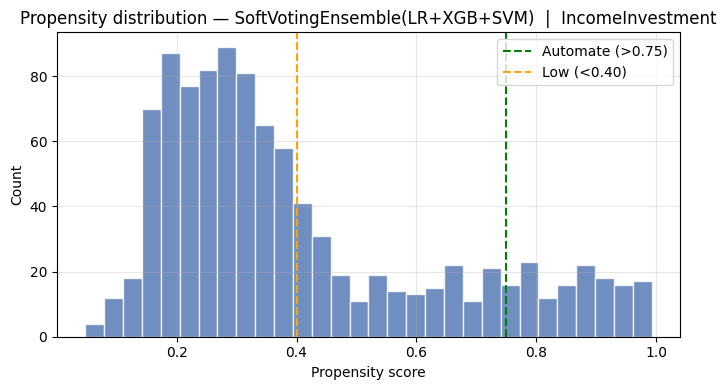

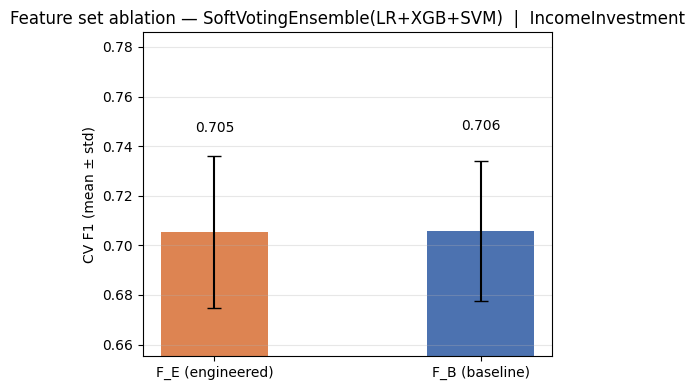

In [7]:
show_soft_voting()

The ensemble achieves CV F1 = 0.705 ± 0.031, placing it between the tree ensembles (0.719)
and LR (0.670) — below the theoretical expectation of outperforming all components. The
reason is structural: LR at CV F1 ~0.670 is a materially weaker component that drags the
average down rather than contributing complementary signal. The ensemble benefit requires
base models of comparable strength; when one component is substantially weaker, soft voting
averages toward mediocrity.

The ablation is equivalent (ΔF1 = −0.001), consistent with XGBoost and RF findings — the
ensemble's tree component learns interactions natively, neutralizing any F_E advantage.
Tuning selected an aggressive SVM (C = 5.0, gamma = 0.01) and conservative LR (C = 0.5),
reflecting the optimizer's attempt to compensate for LR's weaker signal by tightening its
regularization.

The Brier score of 0.1788 is worse than both RF (0.1680) and XGBoost (0.1688), confirming
that averaging calibrated probabilities from a weak LR component degrades aggregate
calibration rather than improving it. The propensity distribution shows a large uncertain
zone (21.4%) — the highest of any model — a direct consequence of the ensemble's probability
averaging pulling scores toward 0.5 when components disagree, which is exactly the regime
where LR's weak signal dominates.

21:54:23  INFO      Training utils.hard_voting_ens...
21:54:24  INFO      Target: IncomeInvestment
21:54:24  INFO        Tuning ensemble (inner 3-fold CV)...
21:55:35  INFO        Best params: {'svm__clf__gamma': 'scale', 'svm__clf__C': 5.0, 'lr__clf__penalty': 'l2', 'lr__clf__C': 1.0}  (inner CV F1=0.700)
21:56:49  INFO        [F_E] CV F1: 0.702 ± 0.029
21:56:58  INFO        [F_E] Test F1=0.636  Precision=0.745
21:56:58  WARNING     Threshold optimisation failed: Model must support predict_proba.
21:58:16  INFO        [F_B] Test F1=0.629  (ΔF_E−F_B=+0.007)
21:58:16  INFO        Saved: c:\Users\giuli\Repositories\fintech-group-work\BusinessCase2\data\pickled_files\hard_voting_ens\incomeinvestment.pkl



===== HardVotingEnsemble(LR+XGB+SVM)  |  IncomeInvestment =====

  ▸ Data split: 80% training / 20% held-out test set, stratified on target class ratio

  ▸ Feature set: F_E — 10 engineered features (lifecycle + savings capacity)

  ▸ Scaling: none (tree-based model, invariant to monotonic transforms) or inside Pipeline components

  ▸ Cross-validation: 10-fold StratifiedKFold (model cloned each fold, scaler refits per fold inside Pipeline)

  ▸ Hyperparameter tuning: RandomizedSearchCV (inner 3-fold CV) — best configuration below
    → svm__clf__gamma = scale
    → svm__clf__C = 5.0
    → lr__clf__penalty = l2
    → lr__clf__C = 1.0

  ──────────────────────────────────────────────────────────
  Metric              CV Mean ± Std    Test @ thr=0.5
  ──────────────────────────────────────────────────────────
  accuracy            0.793 ± 0.017             0.756
  precision           0.783 ± 0.025             0.745
  recall              0.638 ± 0.039             0.555
  f1              

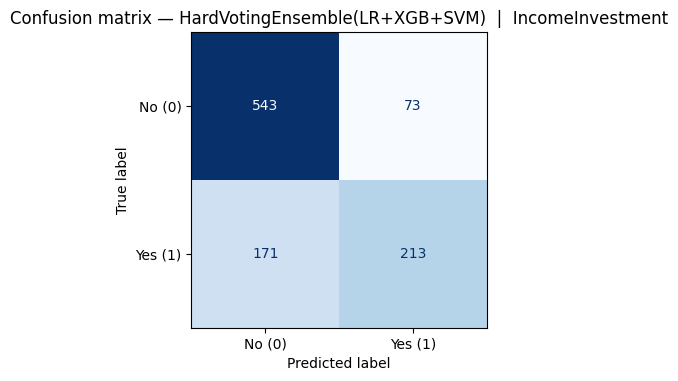

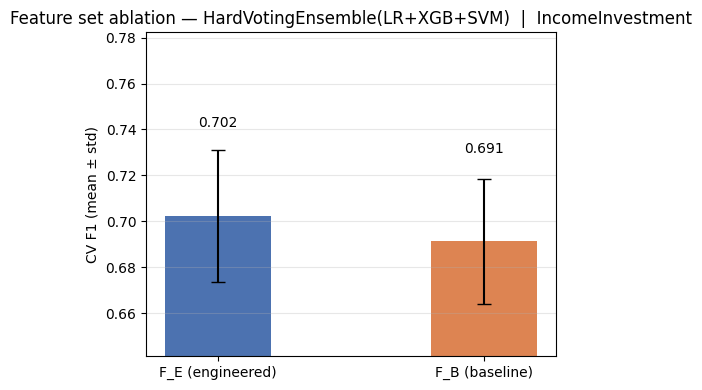

In [8]:
show_hard_voting()

Hard voting achieves CV F1 = 0.702 ± 0.029, marginally below soft voting (0.705) and
confirming the theoretical prediction: discarding probability information before aggregation
costs a small but consistent amount of performance. The gap is narrow because all three
components produce well-separated class predictions for this target — when the majority vote
is unambiguous, hard and soft voting converge.

The ablation shows ΔF1 = +0.011 for F_E, the largest positive delta for any ensemble on
this target. The interpretation label is again a display artifact — the correct reading is
that hard voting's majority rule benefits from the additional signal in the engineered
features, since it cannot exploit the probability magnitude information that would otherwise
compensate for weaker base features.

Test precision of 0.745 falls just below the MiFID II floor of 0.75, which is why threshold
optimisation failed — there is no operating point on the PR curve satisfying the constraint.
This is a direct consequence of hard voting's inability to produce calibrated probabilities,
making threshold selection meaningless. For a MiFID-constrained pipeline, this disqualifies
hard voting from automated recommendation entirely, regardless of its F1 performance.

# Selection of best model

In [13]:
from utils.show_results import show_winner

show_winner()


========= MODEL SELECTION — WILCOXON SIGNED-RANK TESTS =========

======================= IncomeInvestment =======================

  Model                    CV F1 mean±std   Test Prec   Test F1   MiFID OK
  ──────────────────────────────────────────────────────────────────────
  XGBoost                   0.719 ± 0.028       0.821     0.641          ✓
  RandomForest              0.719 ± 0.028       0.841     0.645          ✓
  SoftVoting                0.705 ± 0.031       0.777     0.633          ✓
  HardVoting                0.702 ± 0.029       0.745     0.636          ✗
  MLP                       0.696 ± 0.026       0.802     0.635          ✓
  LR                        0.670 ± 0.030       0.618     0.616          ✗
  NaiveBayes                0.653 ± 0.035       0.640     0.593          ✗

  ✗ Excluded (Precision < 0.75): LR, NaiveBayes, HardVoting

  Top candidate: XGBoost  CV F1 = 0.719
  Wilcoxon test vs RandomForest: statistic=27.000  p=1.0000
  p > 0.05 → not significant. Ap

Three models fail the MiFID II hard constraint (Test Precision ≥ 0.75): LR, Naive Bayes,
and Hard Voting are excluded from automated recommendation regardless of F1 performance.
Hard Voting's disqualification is particularly notable given its competitive CV F1 — it is
a direct consequence of hard voting's inability to produce calibrated probabilities, making
threshold selection to recover precision impossible.

Among the four compliant models, XGBoost and Random Forest are exactly tied at CV F1 =
0.719 ± 0.028. A Wilcoxon signed-rank test yields p = 1.000 — the two models produce
nearly identical per-fold F1 scores, confirming statistical equivalence rather than a
chance tie in means. Occam's razor selects XGBoost as the winner: it is a single sequential
ensemble rather than a bagged collection of 200 trees, has a smaller memory footprint, and
produces SHAP values via TreeExplainer without the additional calibration wrapper that RF
requires.

**Winner: XGBoost** — CV F1 = 0.719, Test Precision = 0.821, Test F1 = 0.641.
The winning model automates recommendations for 20.5% of clients (propensity > 0.75),
routes 5.4% to human advisors, and takes no action on 74.1%.